# Étape 3 — Extraction des caractéristiques

Ce notebook couvre :
1. **Approches traditionnelles** :
   - Haar Cascade (Viola-Jones) : filtres en cascade pour la détection de motifs faciaux
   - Local Binary Patterns (LBP) : analyse des textures locales
   - Histogram of Oriented Gradients (HOG) : structures et formes via histogrammes de gradients
2. **Approche Deep Learning** :
   - DeepFace : extraction d'embeddings faciaux de 128 dimensions
3. **Comparaison et visualisation** des vecteurs de caractéristiques produits

## 0. Imports et configuration

In [3]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import cv2
from skimage.feature import local_binary_pattern, hog
from skimage import exposure

# ── Matplotlib defaults ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"OpenCV    : {cv2.__version__}")
print(f"NumPy     : {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")


OpenCV    : 4.13.0
NumPy     : 2.4.2
Matplotlib: 3.10.8


---
## Chargement des données prétraitées

On réutilise le dataset LFW chargé à l'étape 1 et on applique le pipeline de prétraitement
de l'étape 2 pour obtenir des images prêtes à l'extraction de features.

In [4]:
# ── Chargement du dataset LFW depuis le projet ────────────────────────────────
LFW_DIR = os.path.join('.', 'data', 'lfw')

def load_lfw_from_folder(data_dir):
    """
    Charge LFW depuis une arborescence locale :
    data_dir/person_name/image.jpg
    Retourne images (RGB float32 [0,1]), labels (int), names (np.array[str]).
    """
    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f"Dossier introuvable: {data_dir}")

    person_names = sorted(
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    )

    images_list, labels_list = [], []
    valid_ext = ('.jpg', '.jpeg', '.png', '.bmp')

    for label, person in enumerate(person_names):
        person_dir = os.path.join(data_dir, person)
        for file_name in sorted(os.listdir(person_dir)):
            if not file_name.lower().endswith(valid_ext):
                continue
            img_path = os.path.join(person_dir, file_name)
            bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if bgr is None:
                continue
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            images_list.append(rgb.astype(np.float32) / 255.0)
            labels_list.append(label)

    if len(images_list) == 0:
        raise ValueError(f"Aucune image valide trouvée dans: {data_dir}")

    images_arr = np.array(images_list, dtype=np.float32)
    labels_arr = np.array(labels_list, dtype=np.int32)
    names_arr = np.array(person_names)
    return images_arr, labels_arr, names_arr

print(f"Chargement du dataset LFW local depuis: {LFW_DIR}")
images, labels, names = load_lfw_from_folder(LFW_DIR)
N, H, W, C = images.shape
print(f"Dataset chargé : {N} images, {len(names)} identités, résolution {H}×{W}")


# ── Fonctions utilitaires ─────────────────────────────────────────────────────
def lfw_to_bgr(img_rgb_float):
    """Convertit une image LFW (RGB float32 [0,1]) → BGR uint8."""
    img_uint8 = (img_rgb_float * 255).clip(0, 255).astype(np.uint8)
    return cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)

def bgr_to_rgb(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


# ── Pipeline de prétraitement (repris de l'étape 2) ──────────────────────────
haar_path    = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(haar_path)

TARGET_SIZE = (128, 128)

def preprocess(bgr_img, target_size=TARGET_SIZE):
    """
    Détection → recadrage → niveaux de gris → débruitage → CLAHE
    → redimensionnement → normalisation.
    Retourne une image float32 [0,1] de taille target_size, ou None.
    """
    gray = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    if len(faces) == 0:
        return None
    x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
    face = bgr_img[y:y+h, x:x+w]
    gray_face = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
    denoised  = cv2.GaussianBlur(gray_face, (3, 3), 0)
    clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    equalized = clahe.apply(denoised)
    resized   = cv2.resize(equalized, target_size, interpolation=cv2.INTER_LINEAR)
    return resized.astype(np.float32) / 255.0


# ── Construction d'un échantillon prétraité ───────────────────────────────────
sample_faces, sample_labels = [], []
for i, img_rgb in enumerate(images):
    face = preprocess(lfw_to_bgr(img_rgb))
    if face is not None:
        sample_faces.append(face)
        sample_labels.append(labels[i])
    if len(sample_faces) == 200:   # on prend 200 images détectées
        break

sample_faces  = np.array(sample_faces)
sample_labels = np.array(sample_labels)
print(f"\nÉchantillon prétraité : {len(sample_faces)} images disponibles pour l'extraction.")

Chargement du dataset LFW local depuis: .\data\lfw
Dataset chargé : 13233 images, 5750 identités, résolution 250×250

Échantillon prétraité : 200 images disponibles pour l'extraction.


---
## 3.1 Approches traditionnelles

### 3a. Haar Cascade (Viola-Jones) — détection de motifs faciaux

L'algorithme **Viola-Jones** applique des *features Haar* (différences de sommes
de pixels sur des régions rectangulaires) organisées en cascade pour détecter
des motifs caractéristiques du visage (zone des yeux, arête du nez, bouche).

**Principe de la feature Haar :**
```
score = Σ pixels zone claire − Σ pixels zone sombre
```
L'image intégrale permet ce calcul en O(1) quelle que soit la taille du rectangle.
La cascade rejette ~60 % des fenêtres dès l'étape 1 (2 features seulement),
ce qui rend la détection temps-réel possible.

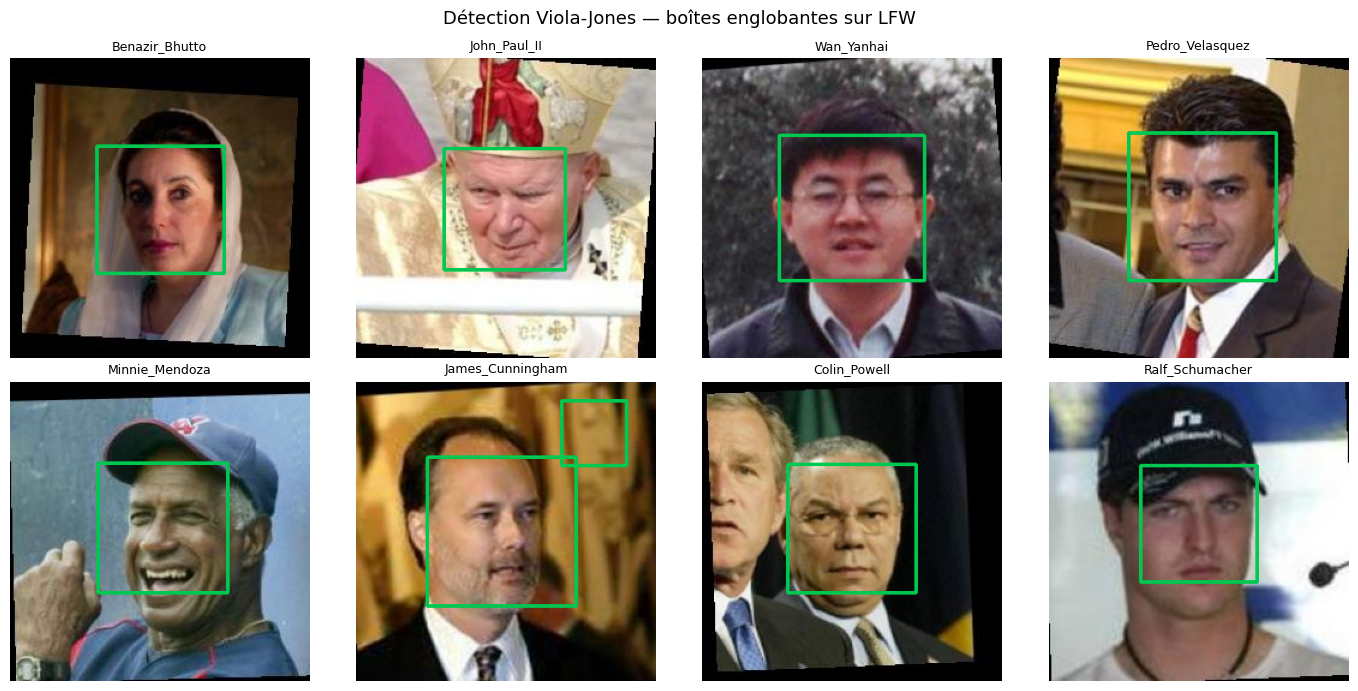

In [5]:
# ── Visualisation des boîtes de détection Haar ────────────────────────────────
# On affiche 8 images LFW avec les bounding boxes détectées par Viola-Jones.

n_demo = 8
rng    = np.random.default_rng(RANDOM_STATE)
idx    = rng.choice(N, n_demo * 3, replace=False)  # pool large pour trouver 8 détections

detected_demos = []
for i in idx:
    bgr  = lfw_to_bgr(images[i])
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    if len(faces) > 0:
        detected_demos.append((bgr, faces, names[labels[i]]))
    if len(detected_demos) == n_demo:
        break

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Détection Viola-Jones — boîtes englobantes sur LFW", fontsize=13)

for ax, (bgr, faces, name) in zip(axes.ravel(), detected_demos):
    display = bgr_to_rgb(bgr.copy())
    for (x, y, w, h) in faces:
        cv2.rectangle(display, (x, y), (x+w, y+h), (0, 200, 80), 2)
    ax.imshow(display)
    ax.set_title(name.split()[-1], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# ── Statistiques de détection Haar sur le dataset complet ─────────────────────
detected, not_detected = 0, 0
for img_rgb in images:
    bgr  = lfw_to_bgr(img_rgb)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    if len(faces) > 0:
        detected += 1
    else:
        not_detected += 1

taux = detected / N * 100
print(f"Taux de détection Viola-Jones sur LFW : {detected}/{N} ({taux:.1f} %)")
print(f"Non détectés : {not_detected} images")
print()
print("Note : LFW contient des visages en profil, partiellement occultés")
print("ou sous éclairage difficile — la cascade frontale n'y répond pas.")

Taux de détection Viola-Jones sur LFW : 13149/13233 (99.4 %)
Non détectés : 84 images

Note : LFW contient des visages en profil, partiellement occultés
ou sous éclairage difficile — la cascade frontale n'y répond pas.


---
### 3b. Local Binary Patterns (LBP) — texture locale

LBP encode la **texture locale** d'un pixel en comparant son intensité à ses
voisins sur un cercle de rayon `r`. On obtient un code binaire par pixel,
puis un **histogramme normalisé** sur l'ensemble de l'image.

**Propriétés clés :**
- Robuste aux variations d'éclairage (comparaisons relatives)
- Très faible coût de calcul
- Vecteur de sortie : `n_points + 2` bins (mode `uniform`)

**Paramètres utilisés dans le projet :**

| Paramètre | Valeur | Rôle |
|-----------|--------|------|
| `radius`  | 1      | Rayon du voisinage circulaire |
| `n_points`| 8      | Nombre de points d'échantillonnage |
| `method`  | uniform| Réduit les codes à 58 + 1 patterns |
| `n_bins`  | 256    | Taille de l'histogramme |

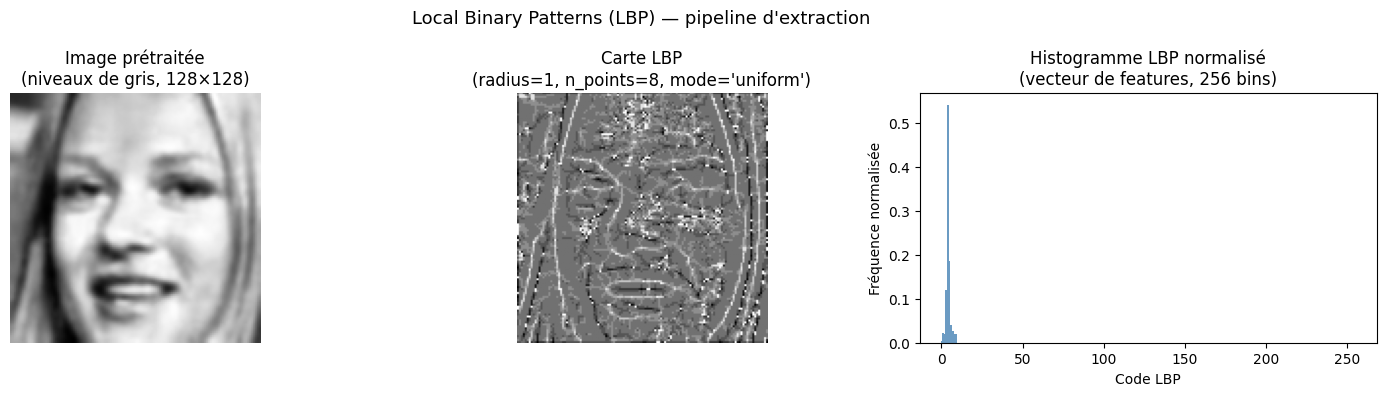

Taille du vecteur LBP : 256 dimensions


In [7]:
# ── Calcul et visualisation LBP ───────────────────────────────────────────────
LBP_RADIUS   = 1
LBP_N_POINTS = 8 * LBP_RADIUS
N_BINS       = 256

# Image de démonstration : première image prétraitée
demo_face = sample_faces[0]                        # float32 [0,1]
demo_uint8 = (demo_face * 255).clip(0,255).astype(np.uint8)

lbp_image = local_binary_pattern(
    demo_uint8, LBP_N_POINTS, LBP_RADIUS, method='uniform'
)

hist, bins = np.histogram(lbp_image.ravel(), bins=N_BINS, range=(0, N_BINS))
hist = hist.astype(np.float32)
hist /= hist.sum() + 1e-7   # normalisation L1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Local Binary Patterns (LBP) — pipeline d'extraction", fontsize=13)

axes[0].imshow(demo_face, cmap='gray')
axes[0].set_title("Image prétraitée\n(niveaux de gris, 128×128)")
axes[0].axis('off')

axes[1].imshow(lbp_image, cmap='gray')
axes[1].set_title(f"Carte LBP\n(radius={LBP_RADIUS}, n_points={LBP_N_POINTS}, mode='uniform')")
axes[1].axis('off')

axes[2].bar(range(N_BINS), hist, width=1.0, color='steelblue', alpha=0.8)
axes[2].set_title(f"Histogramme LBP normalisé\n(vecteur de features, {N_BINS} bins)")
axes[2].set_xlabel("Code LBP")
axes[2].set_ylabel("Fréquence normalisée")

plt.tight_layout()
plt.show()

print(f"Taille du vecteur LBP : {hist.shape[0]} dimensions")

In [8]:
# ── Extraction LBP sur tout l'échantillon ────────────────────────────────────
def extract_lbp(face_float32, radius=LBP_RADIUS, n_points=LBP_N_POINTS, n_bins=N_BINS):
    """Retourne l'histogramme LBP normalisé (float32, shape=(n_bins,))."""
    uint8 = (face_float32 * 255).clip(0,255).astype(np.uint8)
    lbp   = local_binary_pattern(uint8, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    hist = hist.astype(np.float32)
    hist /= hist.sum() + 1e-7
    return hist

X_lbp = np.array([extract_lbp(f) for f in sample_faces])
print(f"Matrice de features LBP : {X_lbp.shape}")
print(f"  → {X_lbp.shape[0]} images  ×  {X_lbp.shape[1]} dimensions")

Matrice de features LBP : (200, 256)
  → 200 images  ×  256 dimensions


---
### 3c. Histogram of Oriented Gradients (HOG) — formes et structures

HOG capture les **orientations de gradients** (contours, formes) dans des cellules
locales, puis normalise les histogrammes par blocs pour une invariance partielle
à l'éclairage et au contraste.

**Pipeline HOG :**
1. Calcul des gradients (Gx, Gy) par dérivée discrète
2. Orientation θ = arctan(Gy/Gx) et amplitude |G|
3. Histogramme d'orientations par cellule (8×8 pixels)
4. Normalisation L2 par blocs de 2×2 cellules
5. Concaténation → vecteur final

**Paramètres :**

| Paramètre | Valeur | Rôle |
|-----------|--------|------|
| `orientations` | 9 | Nombre de bins d'angle (0°–180°) |
| `pixels_per_cell` | (8, 8) | Taille d'une cellule |
| `cells_per_block` | (2, 2) | Blocs de normalisation |
| `block_norm` | L2-Hys | Normalisation robuste |

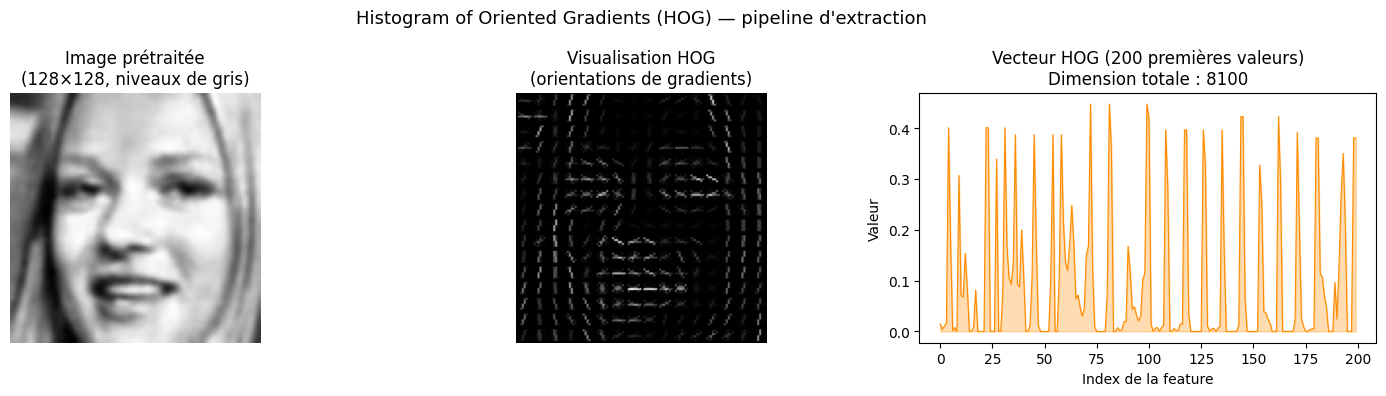

Taille du vecteur HOG : 8100 dimensions


In [9]:
# ── Calcul et visualisation HOG ───────────────────────────────────────────────
HOG_ORIENTATIONS     = 9
HOG_PIXELS_PER_CELL  = (8, 8)
HOG_CELLS_PER_BLOCK  = (2, 2)

hog_features, hog_image = hog(
    demo_face,
    orientations=HOG_ORIENTATIONS,
    pixels_per_cell=HOG_PIXELS_PER_CELL,
    cells_per_block=HOG_CELLS_PER_BLOCK,
    block_norm='L2-Hys',
    visualize=True,
    feature_vector=True,
)

# Amélioration du contraste pour visualisation
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Histogram of Oriented Gradients (HOG) — pipeline d'extraction", fontsize=13)

axes[0].imshow(demo_face, cmap='gray')
axes[0].set_title("Image prétraitée\n(128×128, niveaux de gris)")
axes[0].axis('off')

axes[1].imshow(hog_image_rescaled, cmap='gray')
axes[1].set_title("Visualisation HOG\n(orientations de gradients)")
axes[1].axis('off')

axes[2].plot(hog_features[:200], color='darkorange', linewidth=0.8)
axes[2].fill_between(range(200), hog_features[:200], alpha=0.3, color='darkorange')
axes[2].set_title(f"Vecteur HOG (200 premières valeurs)\nDimension totale : {len(hog_features)}")
axes[2].set_xlabel("Index de la feature")
axes[2].set_ylabel("Valeur")

plt.tight_layout()
plt.show()

print(f"Taille du vecteur HOG : {hog_features.shape[0]} dimensions")

In [10]:
# ── Extraction HOG sur tout l'échantillon ────────────────────────────────────
def extract_hog(face_float32):
    """Retourne le vecteur HOG (float64 normalisé)."""
    features = hog(
        face_float32,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        feature_vector=True,
    )
    return features.astype(np.float32)

X_hog = np.array([extract_hog(f) for f in sample_faces])
print(f"Matrice de features HOG : {X_hog.shape}")
print(f"  → {X_hog.shape[0]} images  ×  {X_hog.shape[1]} dimensions")

Matrice de features HOG : (200, 8100)
  → 200 images  ×  8100 dimensions


---
## 3.2 Approche Deep Learning — DeepFace (embeddings faciaux)

### Qu'est-ce que DeepFace ?

DeepFace est une bibliotheque Python qui encapsule plusieurs reseaux de neurones convolutionnels (CNN) pre-entraines specialises dans la reconnaissance faciale.

Elle transforme chaque image de visage en un vecteur numerique de 128 dimensions appele *embedding*. Ce vecteur capture l'identite unique d'un visage :
- Deux photos de la **meme personne** produisent des embeddings **proches** (similarite cosinus proche de 1)
- Deux photos de **personnes differentes** produisent des embeddings **eloignes** (similarite proche de 0)

### Modeles disponibles dans DeepFace

| Modele | Annee | Dimensions | Particularite |
|--------|-------|------------|---------------|
| **VGG-Face** | 2015 | 4096 | Pionnier, tres lourd |
| **Facenet** | 2015 | 128 | Leger, precis — **utilise dans ce projet** |
| **DeepFace (Facebook)** | 2014 | 4096 | Modele original |
| **ArcFace** | 2019 | 512 | Etat de l'art actuel |
| **OpenFace** | 2016 | 128 | Open-source, leger |

> **Choix du projet :** Facenet — meilleur compromis precision / vitesse / taille (~90 Mo de poids).


---
### Pipeline complet de DeepFace — de l'image brute à l'embedding

Le pipeline se déroule en **4 étapes séquentielles** :

```
┌──────────────────┐    ┌──────────────────────────┐    ┌──────────────────────┐    ┌─────────────────────┐
│  1. DÉTECTION    │───▶│   2. ALIGNEMENT           │───▶│  3. NORMALISATION    │───▶│  4. CNN → EMBEDDING │
│                  │    │                           │    │                      │    │                     │
│  Localise le     │    │  Détecte 5 landmarks :    │    │  Resize → 160×160    │    │  Facenet produit    │
│  visage via      │    │  yeux, nez, coins bouche  │    │  Centrage pixel      │    │  un vecteur de      │
│  backend OpenCV  │    │  → transformation affine  │    │  mean=0, std=1       │    │  128 float32        │
│                  │    │  pour redresser le visage │    │                      │    │  = IDENTITÉ du      │
│                  │    │                           │    │                      │    │  visage             │
└──────────────────┘    └──────────────────────────┘    └──────────────────────┘    └─────────────────────┘
    detector_backend=          5 pts clés détectés            normalisation                128 dims
      'retinaface/opencv'                   + rotation/crop                float32                    float32
```

> **Pourquoi l'alignement est crucial ?** Sans lui, un visage légèrement incliné produit un embedding très différent. DeepFace repositionne toujours les yeux et la bouche aux mêmes coordonnées, assurant l'invariance à la pose.


---
### Étape 1 — Installation et import de DeepFace

On installe DeepFace si nécessaire et on vérifie son bon fonctionnement.
Le premier appel téléchargera automatiquement les poids Facenet (~90 Mo).


In [11]:
# ── Installation (décommenter si nécessaire) ─────────────────────────────────
# !pip install deepface -q

# ── Import avec vérification ──────────────────────────────────────────────────
try:
    from deepface import DeepFace
    import tensorflow as tf
    DEEPFACE_AVAILABLE = True
    print("DeepFace importé avec succès.")
    print(f"   Version TensorFlow : {tf.__version__}")
except ImportError as e:
    DEEPFACE_AVAILABLE = False
    print(" DeepFace non installé.")
    print(f"   Erreur : {e}")
    print("   → Exécutez :  pip install deepface")
    print("   Les cellules suivantes seront ignorées automatiquement.")


DeepFace importé avec succès.
   Version TensorFlow : 2.21.0


---
### Étape 2 — Détection & alignement du visage (avec exemples visuels)

Avant d'extraire l'embedding, DeepFace **localise** le visage et **l'aligne automatiquement**.
On illustre ici la détection avec `retinaface` (plus précis pour les landmarks),
avec repli automatique vers `opencv` si nécessaire :
- **Ligne 1** : image originale
- **Ligne 2** : bounding box + landmarks (yeux, nez, bouche en orange)
- **Ligne 3** : visage aligné prêt pour le CNN (160×160 pixels)


26-04-13 19:59:20 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: C:\Users\ihebk\.deepface\weights\retinaface.h5
100%|██████████| 119M/119M [01:18<00:00, 1.50MB/s] 


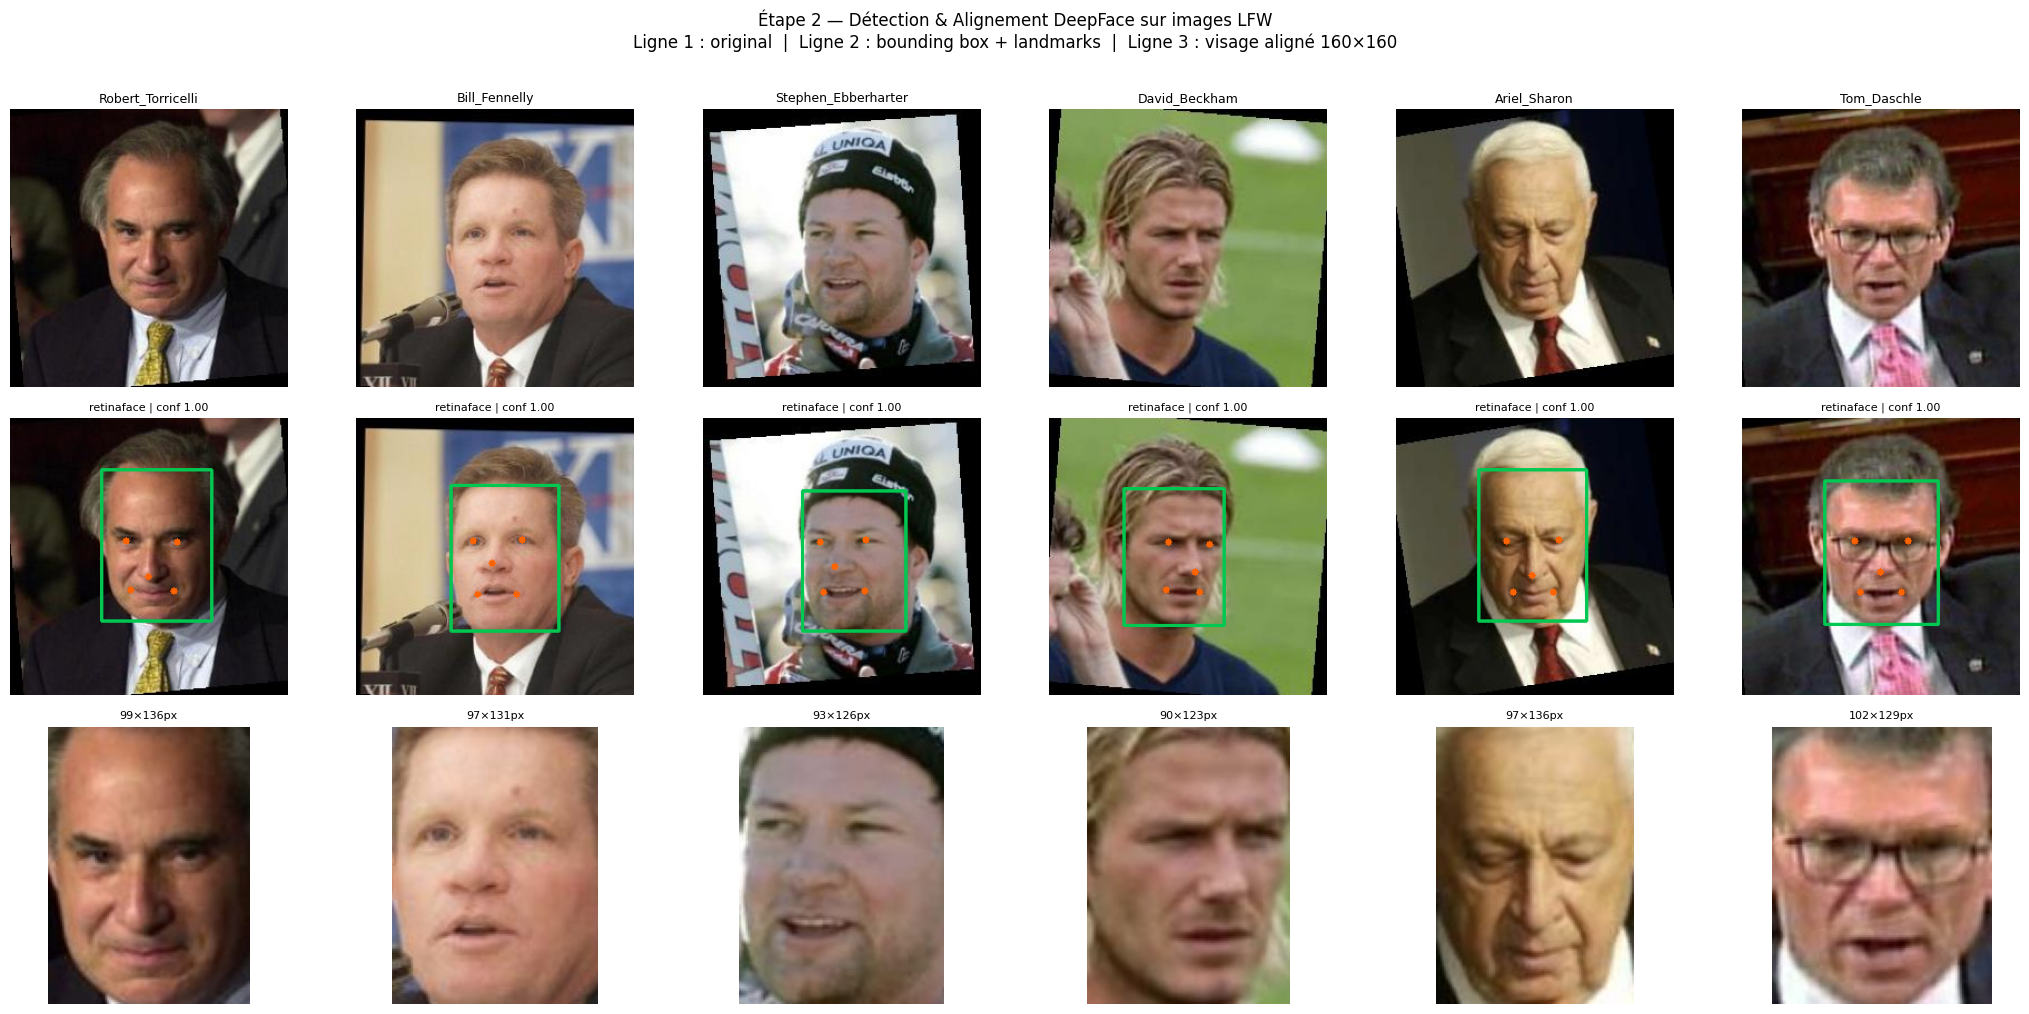

✅ Détection et alignement illustrés sur 6 images.


In [19]:
# ── Visualisation : image brute → détection → alignement ────────────────────
if DEEPFACE_AVAILABLE:
    rng_demo = np.random.default_rng(RANDOM_STATE)
    demo_indices = rng_demo.choice(N, 40, replace=False)

    PRIMARY_BACKEND = 'retinaface'
    FALLBACK_BACKEND = 'opencv'

    def _extract_with_fallback(bgr_img):
        """Essaie retinaface (landmarks), puis opencv en repli."""
        try:
            faces = DeepFace.extract_faces(
                img_path=bgr_img,
                detector_backend=PRIMARY_BACKEND,
                align=True,
                enforce_detection=True,
            )
            if faces:
                return faces[0], PRIMARY_BACKEND
        except Exception:
            pass

        try:
            faces = DeepFace.extract_faces(
                img_path=bgr_img,
                detector_backend=FALLBACK_BACKEND,
                align=True,
                enforce_detection=True,
            )
            if faces:
                return faces[0], FALLBACK_BACKEND
        except Exception:
            pass

        return None, None

    def _collect_landmarks(face_info):
        """Récupère les landmarks depuis différents formats retournés par DeepFace."""
        points = []
        area = face_info.get('facial_area', {})

        # Format 1: clés directes dans facial_area
        for key in ['left_eye', 'right_eye', 'nose', 'mouth_left', 'mouth_right']:
            p = area.get(key)
            if p is not None and len(p) >= 2:
                points.append((int(p[0]), int(p[1])))

        # Format 2: dict face_info['landmarks']
        lm_dict = face_info.get('landmarks')
        if isinstance(lm_dict, dict):
            for key in ['left_eye', 'right_eye', 'nose', 'mouth_left', 'mouth_right']:
                p = lm_dict.get(key)
                if p is not None and len(p) >= 2:
                    points.append((int(p[0]), int(p[1])))

        # Supprime doublons tout en gardant l'ordre
        unique_points = []
        seen = set()
        for p in points:
            if p not in seen:
                unique_points.append(p)
                seen.add(p)
        return unique_points

    results_demo = []
    for idx in demo_indices:
        bgr = lfw_to_bgr(images[idx])
        face_info, backend_used = _extract_with_fallback(bgr)
        if face_info is not None:
            results_demo.append((bgr, face_info, names[labels[idx]], backend_used))
        if len(results_demo) == 6:
            break

    if results_demo:
        fig, axes = plt.subplots(3, len(results_demo), figsize=(3.5 * len(results_demo), 10))
        fig.suptitle(
            "Étape 2 — Détection & Alignement DeepFace sur images LFW\n"
            "Ligne 1 : original  |  Ligne 2 : bounding box + landmarks  |  Ligne 3 : visage aligné 160×160",
            fontsize=12, y=1.01
        )
        row_labels = ["Original", "Détection", "Aligné (160×160)"]
        for row in range(3):
            axes[row, 0].set_ylabel(row_labels[row], fontsize=10, labelpad=6)

        for col, (bgr_orig, face_info, person_name, backend_used) in enumerate(results_demo):
            rgb_orig = bgr_to_rgb(bgr_orig.copy())
            area     = face_info.get('facial_area', {})
            aligned  = face_info.get('face')

            # Ligne 1 : original
            axes[0, col].imshow(rgb_orig)
            axes[0, col].set_title(person_name.split()[-1], fontsize=9)
            axes[0, col].axis('off')

            # Ligne 2 : bounding box + landmarks
            display_bb = rgb_orig.copy()
            x, y = int(area.get('x', 0)), int(area.get('y', 0))
            w, h = int(area.get('w', 0)), int(area.get('h', 0))
            if w > 0 and h > 0:
                cv2.rectangle(display_bb, (x, y), (x + w, y + h), (0, 200, 80), 2)

            lm_points = _collect_landmarks(face_info)
            for (lx, ly) in lm_points:
                cv2.circle(display_bb, (lx, ly), 3, (255, 100, 0), -1)

            axes[1, col].imshow(display_bb)
            conf = face_info.get('confidence', 0)
            title = f"{backend_used} | conf {conf:.2f}" if conf else f"{backend_used}"
            if len(lm_points) == 0:
                title += " | no landmarks"
            axes[1, col].set_title(title, fontsize=8)
            axes[1, col].axis('off')

            # Ligne 3 : aligné
            if aligned is None:
                aligned_show = np.zeros((160, 160, 3), dtype=np.uint8)
            else:
                aligned_show = aligned
                if aligned_show.dtype != np.uint8:
                    aligned_show = (aligned_show * 255).clip(0, 255).astype(np.uint8)
            axes[2, col].imshow(aligned_show)
            axes[2, col].set_title(f"{aligned_show.shape[1]}×{aligned_show.shape[0]}px", fontsize=8)
            axes[2, col].axis('off')

        plt.tight_layout()
        plt.show()
        print(f"✅ Détection et alignement illustrés sur {len(results_demo)} images.")
    else:
        print("⚠️  Aucune détection réussie sur l'échantillon.")
else:
    print("[Ignoré] DeepFace non disponible.")


---
### Étape 3 — Fonctions d'extraction et métriques de similarité

On définit la fonction d'extraction d'embedding et les deux métriques
utilisées pour comparer des visages :
- **Similarité cosinus** ∈ [-1, 1] : mesure l'angle entre vecteurs
- **Distance euclidienne** (L2) : mesure la distance dans l'espace 128D


In [13]:
# ── Fonctions utilitaires ────────────────────────────────────────────────────

def extract_deepface_embedding(bgr_img, model='Facenet', detector='opencv'):
    """
    Extrait un embedding DeepFace depuis une image BGR numpy.
    Retourne un np.ndarray float32 de shape (128,), ou None en cas d'echec.
    """
    if not DEEPFACE_AVAILABLE:
        return None
    try:
        result = DeepFace.represent(
            img_path=bgr_img,
            model_name=model,
            detector_backend=detector,
            enforce_detection=True,
        )
        # DeepFace >= 0.0.75 retourne une liste de dicts
        embedding = result[0]['embedding'] if isinstance(result, list) else result['embedding']
        return np.array(embedding, dtype=np.float32)
    except Exception:
        return None


def cosine_similarity(a, b):
    """Similarite cosinus dans [-1, 1]. Proche de 1 = meme personne."""
    a = a / (np.linalg.norm(a) + 1e-8)
    b = b / (np.linalg.norm(b) + 1e-8)
    return float(np.dot(a, b))


def euclidean_distance(a, b):
    """Distance L2. Proche de 0 = meme personne."""
    return float(np.linalg.norm(a - b))


print("✅ Fonctions definies :")
print("   extract_deepface_embedding(bgr_img) -> np.ndarray(128,)")
print("   cosine_similarity(a, b)             -> float ∈ [-1, 1]")
print("   euclidean_distance(a, b)            -> float >= 0")


✅ Fonctions definies :
   extract_deepface_embedding(bgr_img) -> np.ndarray(128,)
   cosine_similarity(a, b)             -> float ∈ [-1, 1]
   euclidean_distance(a, b)            -> float >= 0


---
### Étape 4 — Extraction et visualisation d'un seul embedding

On extrait le vecteur de 128 dimensions pour **une image** et on l'analyse :
- Sa structure complète (valeurs positives et négatives)
- Sa distribution statistique
- Sa norme L2 (magnitude globale)


Image de demonstration : AJ_Cook
Taille originale       : 250x250 pixels

✅ Embedding extrait avec succes !
   Dimension  : 128
   Type       : float32
   Min / Max  : -2.0383 / 2.3088
   Norme L2   : 11.8022
   Moyenne    : 0.0205

   10 premieres valeurs :
   [-0.6415 -0.4888  0.1012 -0.3874 -1.2903 -0.9112  2.3088  0.3606  0.0915
  0.6175]


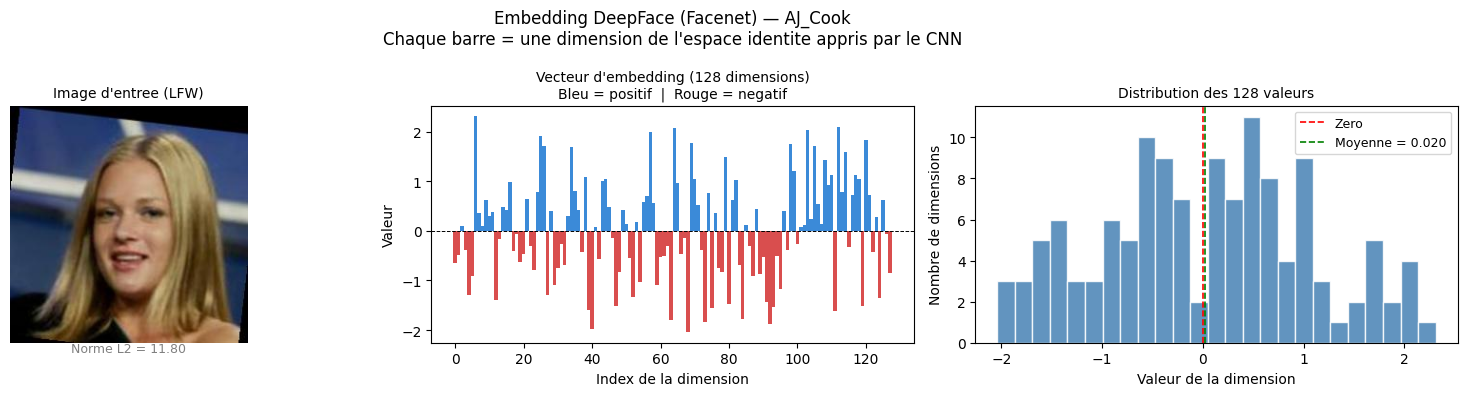

In [14]:
# ── Extraction pas-a-pas + visualisation d'un embedding ──────────────────────
if DEEPFACE_AVAILABLE:
    bgr_demo  = lfw_to_bgr(images[0])
    name_demo = names[labels[0]]

    print(f"Image de demonstration : {name_demo}")
    print(f"Taille originale       : {bgr_demo.shape[1]}x{bgr_demo.shape[0]} pixels")

    emb_demo = extract_deepface_embedding(bgr_demo)

    if emb_demo is not None:
        print(f"\n✅ Embedding extrait avec succes !")
        print(f"   Dimension  : {emb_demo.shape[0]}")
        print(f"   Type       : {emb_demo.dtype}")
        print(f"   Min / Max  : {emb_demo.min():.4f} / {emb_demo.max():.4f}")
        print(f"   Norme L2   : {np.linalg.norm(emb_demo):.4f}")
        print(f"   Moyenne    : {emb_demo.mean():.4f}")
        print(f"\n   10 premieres valeurs :")
        print("  ", np.round(emb_demo[:10], 4))

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        fig.suptitle(
            f"Embedding DeepFace (Facenet) — {name_demo}\n"
            "Chaque barre = une dimension de l'espace identite appris par le CNN",
            fontsize=12
        )

        # Image originale
        axes[0].imshow(bgr_to_rgb(bgr_demo))
        axes[0].set_title("Image d'entree (LFW)", fontsize=10)
        axes[0].axis('off')
        axes[0].text(0.5, -0.04, f"Norme L2 = {np.linalg.norm(emb_demo):.2f}",
                     transform=axes[0].transAxes, ha='center', fontsize=9, color='gray')

        # Vecteur 128D
        colors = ['#1976D2' if v >= 0 else '#D32F2F' for v in emb_demo]
        axes[1].bar(range(128), emb_demo, width=1.0, color=colors, alpha=0.85)
        axes[1].axhline(0, color='black', linewidth=0.7, linestyle='--')
        axes[1].set_title("Vecteur d'embedding (128 dimensions)\nBleu = positif  |  Rouge = negatif", fontsize=10)
        axes[1].set_xlabel("Index de la dimension")
        axes[1].set_ylabel("Valeur")

        # Distribution
        axes[2].hist(emb_demo, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
        axes[2].axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero')
        axes[2].axvline(emb_demo.mean(), color='green', linestyle='--', linewidth=1.2,
                        label=f'Moyenne = {emb_demo.mean():.3f}')
        axes[2].set_title("Distribution des 128 valeurs", fontsize=10)
        axes[2].set_xlabel("Valeur de la dimension")
        axes[2].set_ylabel("Nombre de dimensions")
        axes[2].legend(fontsize=9)

        plt.tight_layout()
        plt.show()
    else:
        print("⚠️  Echec de l'extraction — visage non detecte.")
else:
    print("[Ignore] DeepFace non disponible.")


---
### Étape 5 — Vérification d'identité : même personne vs personnes différentes

L'intérêt fondamental des embeddings est la **vérification d'identité**.
On illustre la différence entre :

| Scénario | Similarité cosinus | Distance L2 | Interprétation |
|----------|--------------------|-------------|----------------|
| **Même personne** | ≈ 0.6 – 1.0 | ≈ 0 – 10 | Identité confirmée  |
| **Personnes différentes** | ≈ -0.2 – 0.5 | >10 | Identités distinctes  |

> **Seuil typique Facenet** : similarité cosinus > **0.60** → même personne


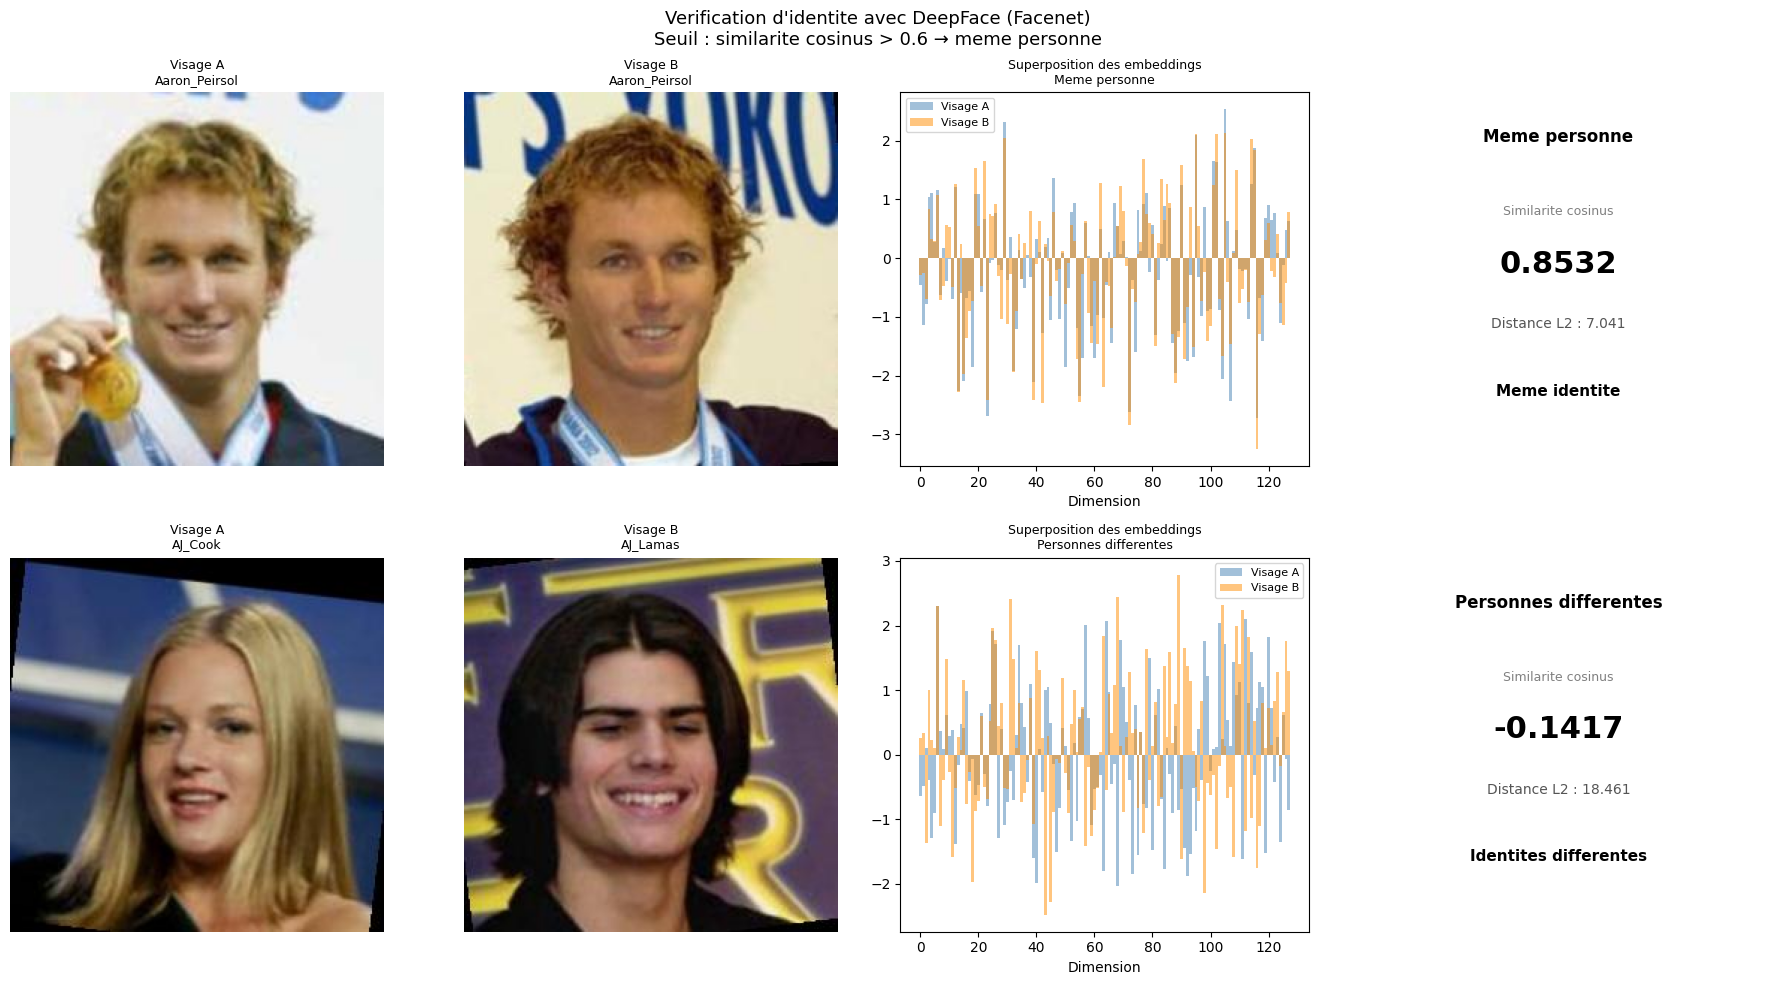

  Meme personne                  → sim=0.853  dist=7.041
  Personnes differentes          → sim=-0.142  dist=18.461


In [20]:
# ── Comparaison same-person vs different-person ──────────────────────────────
from config import COSINE_THRESHOLD


if DEEPFACE_AVAILABLE:
    from collections import defaultdict

    identity_index = defaultdict(list)
    for i, lbl in enumerate(labels):
        identity_index[lbl].append(i)

    # Paire meme identite
    same_pair_indices = None
    for lbl, idxs in identity_index.items():
        if len(idxs) >= 2:
            same_pair_indices = (idxs[0], idxs[1])
            same_label = lbl
            break

    # Paire identites differentes
    all_labels = [l for l, idxs in identity_index.items() if len(idxs) >= 1]
    diff_pair_labels = all_labels[:2]
    diff_pair_indices = (identity_index[diff_pair_labels[0]][0],
                         identity_index[diff_pair_labels[1]][0])

    def safe_embed(img_idx):
        bgr = lfw_to_bgr(images[img_idx])
        return extract_deepface_embedding(bgr)

    pairs = []
    if same_pair_indices:
        e1 = safe_embed(same_pair_indices[0])
        e2 = safe_embed(same_pair_indices[1])
        if e1 is not None and e2 is not None:
            pairs.append({
                'title': 'Meme personne',
                'nameA': names[same_label].split()[-1],
                'nameB': names[same_label].split()[-1],
                'imgA': images[same_pair_indices[0]],
                'imgB': images[same_pair_indices[1]],
                'embA': e1, 'embB': e2
            })

    e3 = safe_embed(diff_pair_indices[0])
    e4 = safe_embed(diff_pair_indices[1])
    if e3 is not None and e4 is not None:
        pairs.append({
            'title': 'Personnes differentes',
            'nameA': names[diff_pair_labels[0]].split()[-1],
            'nameB': names[diff_pair_labels[1]].split()[-1],
            'imgA': images[diff_pair_indices[0]],
            'imgB': images[diff_pair_indices[1]],
            'embA': e3, 'embB': e4
        })

    if pairs:
        fig, axes = plt.subplots(len(pairs), 4, figsize=(18, 5 * len(pairs)))
        if len(pairs) == 1:
            axes = axes[np.newaxis, :]

        fig.suptitle(
            "Verification d'identite avec DeepFace (Facenet)\n"
            f"Seuil : similarite cosinus > {COSINE_THRESHOLD} → meme personne",
            fontsize=13
        )

        for row, p in enumerate(pairs):
            sim  = cosine_similarity(p['embA'], p['embB'])
            dist = euclidean_distance(p['embA'], p['embB'])
            is_same = 'Meme' in p['title']
            color_main = 'black'
            color_bg   = 'white'
            verdict    = 'Meme identite' if (sim > COSINE_THRESHOLD) else 'Identites differentes'

            # Image A
            axes[row, 0].imshow((p['imgA'] * 255).clip(0,255).astype(np.uint8))
            axes[row, 0].set_title(f"Visage A\n{p['nameA']}", fontsize=9)
            axes[row, 0].axis('off')

            # Image B
            axes[row, 1].imshow((p['imgB'] * 255).clip(0,255).astype(np.uint8))
            axes[row, 1].set_title(f"Visage B\n{p['nameB']}", fontsize=9)
            axes[row, 1].axis('off')

            # Embeddings superposes
            axes[row, 2].bar(range(128), p['embA'], width=1.0, color='steelblue', alpha=0.5, label='Visage A')
            axes[row, 2].bar(range(128), p['embB'], width=1.0, color='darkorange', alpha=0.5, label='Visage B')
            axes[row, 2].set_title(f"Superposition des embeddings\n{p['title']}", fontsize=9)
            axes[row, 2].set_xlabel("Dimension")
            axes[row, 2].legend(fontsize=8)

            # Metriques
            ax_m = axes[row, 3]
            ax_m.axis('off')
            props = [
                (0.50, 0.88, p['title'],           12, 'bold', color_main),
                (0.50, 0.68, 'Similarite cosinus', 9,  'normal', 'gray'),
                (0.50, 0.54, f"{sim:.4f}",         22, 'bold', color_main),
                (0.50, 0.38, f"Distance L2 : {dist:.3f}", 10, 'normal', '#555'),
                (0.50, 0.20, verdict,              11, 'bold', color_main),
            ]
            for (xx, yy, txt, fs, fw, fc) in props:
                kw = dict(ha='center', va='center', fontsize=fs, fontweight=fw, color=fc,
                          transform=ax_m.transAxes)

                ax_m.text(xx, yy, txt, **kw)

        plt.tight_layout()
        plt.show()
        for p in pairs:
            sim  = cosine_similarity(p['embA'], p['embB'])
            dist = euclidean_distance(p['embA'], p['embB'])
            print(f"  {p['title']:30s} → sim={sim:.3f}  dist={dist:.3f}")
    else:
        print("⚠️  Embeddings non disponibles pour la comparaison.")
else:
    print("[Ignore] DeepFace non disponible.")


---
### Points cles a retenir sur DeepFace

**Avantages**

- **128 dimensions seulement** (vs 256 LBP, ~3780 HOG) — compact mais expressif
- **Robustesse** aux variations d'eclairage, de pose, d'expression
- **Alignement automatique** — pas de pretraitement manuel necessaire
- **Etat de l'art** sur les benchmarks (LFW, MegaFace, IJB-C)
- **Multi-modeles** — Facenet, ArcFace, VGG-Face interchangeables

**Inconvenients**

- **Boite noire** — dimensions non interpretables humainement
- **Vitesse** — ~0.3 s/image CPU (vs < 0.01 s pour LBP/HOG)
- **Dependances lourdes** — TensorFlow + poids (~90 Mo)
- **GPU recommande** pour les applications temps-reel
- **Biais potentiels** selon les donnees d'entrainement du modele

> **Conclusion** : DeepFace produit les embeddings les plus discriminants pour la classification. Son seul handicap est la vitesse — acceptable pour un pipeline offline sur LFW. Les 128 dimensions extraites ici seront utilisees en entree le classifieur SVM .


---
## Comparaison des approches — résumé visuel

On compare côte à côte les features extraites par chaque méthode sur la même image.

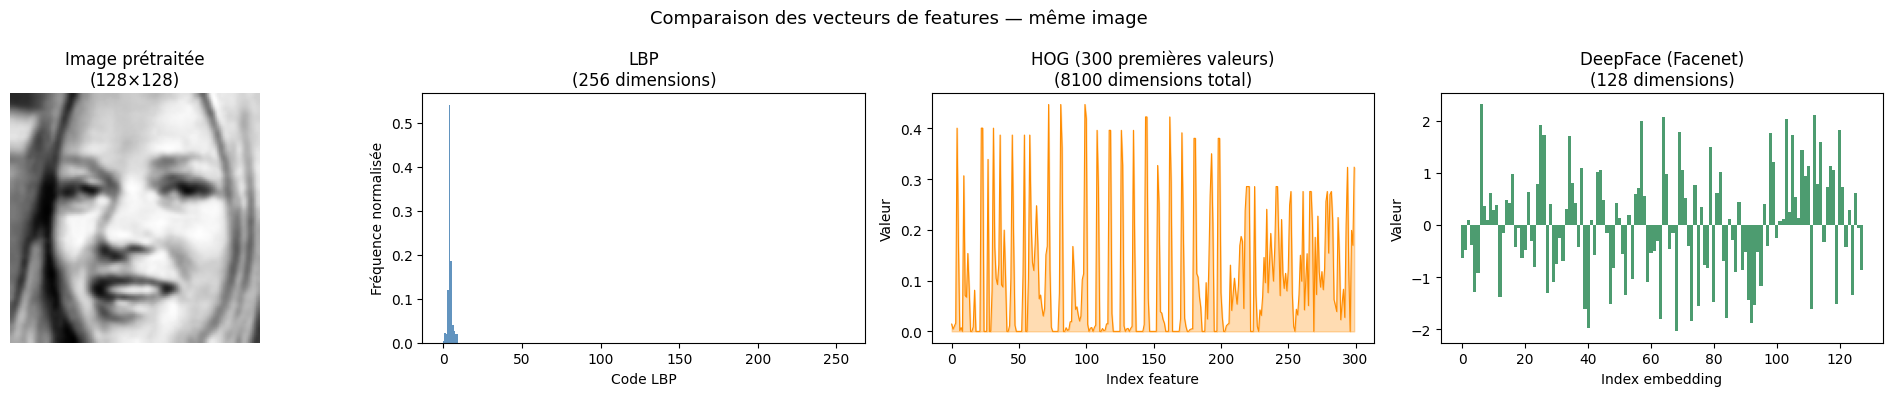

In [18]:
# ── Comparaison des vecteurs de features sur une même image ───────────────────
face_demo  = sample_faces[0]
lbp_feat   = extract_lbp(face_demo)
hog_feat   = extract_hog(face_demo)

# Récupère un embedding DeepFace de façon robuste (selon les cellules exécutées).
deepface_feat = None
if DEEPFACE_AVAILABLE:
    if 'embeddings' in globals() and len(embeddings) > 0:
        deepface_feat = np.asarray(embeddings[0], dtype=np.float32)
    elif 'emb_demo' in globals() and emb_demo is not None:
        deepface_feat = np.asarray(emb_demo, dtype=np.float32)
    else:
        deepface_feat = extract_deepface_embedding(lfw_to_bgr(images[0]))

n_plots = 4 if deepface_feat is not None else 3
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
fig.suptitle("Comparaison des vecteurs de features — même image", fontsize=13)

axes[0].imshow(face_demo, cmap='gray')
axes[0].set_title("Image prétraitée\n(128×128)")
axes[0].axis('off')

axes[1].bar(range(len(lbp_feat)), lbp_feat, width=1.0, color='steelblue', alpha=0.85)
axes[1].set_title(f"LBP\n({len(lbp_feat)} dimensions)")
axes[1].set_xlabel("Code LBP")
axes[1].set_ylabel("Fréquence normalisée")

axes[2].plot(hog_feat[:300], color='darkorange', linewidth=0.8)
axes[2].fill_between(range(300), hog_feat[:300], alpha=0.3, color='darkorange')
axes[2].set_title(f"HOG (300 premières valeurs)\n({len(hog_feat)} dimensions total)")
axes[2].set_xlabel("Index feature")
axes[2].set_ylabel("Valeur")

if deepface_feat is not None:
    axes[3].bar(range(len(deepface_feat)), deepface_feat, width=1.0, color='seagreen', alpha=0.85)
    axes[3].set_title(f"DeepFace (Facenet)\n({len(deepface_feat)} dimensions)")
    axes[3].set_xlabel("Index embedding")
    axes[3].set_ylabel("Valeur")

plt.tight_layout()
plt.show()

---
## Bilan

| Méthode | Type | Dimensions | Robustesse éclairage | Vitesse | Usage |
|---------|------|-----------|----------------------|---------|-------|
| **Haar Cascade** | Traditionnel | N/A (détection) | Faible | Très rapide | Détection de visages |
| **LBP** | Traditionnel | 256 | Robuste | Rapide | Reconnaissance |
| **HOG** | Traditionnel | ~3 780* | Moyenne | Moyen | Détection + Reconnaissance |
| **DeepFace (Facenet)** | Deep Learning | 128 | Très robuste | Lent (GPU recommandé) | Reconnaissance avancée |

*Pour une image 128×128, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2).

**Conclusion** : LBP et HOG sont interprétables et légers, adaptés aux systèmes embarqués.
DeepFace produit des embeddings sémantiquement riches, bien meilleurs pour la
vérification d'identité, au prix d'un coût de calcul plus élevé.

Les vecteurs extraits ici seront utilisés en entrée des classifieurs (SVM)
définis dans les modules `classifiers/` du projet.